# FORMATIVE ASSESSMENT OF ADOLESCENT GIRLS AND YOUNG WOMEN’S HIV, GENDER-BASED VIOLENCE AND SEXUAL AND REPRODUCTIVE HEALTH STATUS

## Background
Teenage pregnancy and motherhood have been a major health and social concern in Uganda as it infringes upon the human rights of girls but also hinders their ability to achieve their full socioeconomic development. Teenagers who engage in sexual intercourse at a young age face an elevated risk of becoming pregnant and giving birth. The 2022 UDHS indicated that 23.5% of women age 15-19 had initiated childbearing by the time of the survey, with 18.4% having already had a live birth, while 5.1% were pregnant with their first child.

Patterns by background characteristics:
* By age 16, 1 in every 10 women age 15-19 has begun childbearing. This percentage significantly rises to almost 4 out of every 10 by the time they reach 18 (Table 5.12).
* Teenagers in rural areas started childbearing earlier than those in urban areas. Twenty five percent of women age 15-19 in rural areas have begun childbearing, compared with 21% in urban areas.
* Teenage childbearing varies by region. The percentage of women age 15-19 who have begun childbearing ranges from 15% in Kigezi region to 28 % -30% in Busoga and Bukedi sub regions.
* The proportion of women age 15-19 who have begun childbearing decreases with both education and wealth.

Regions: The selection of the districts that we surveyed was informed by HIV prevalence dynamics and implementing partner support: we went to districts where there were Global Fund-supported implementing partners working to reduce the new number of new HIV infections among AGYW, improve SRH (e.g. reduce teenage pregnancy) and GBV indicators in the targeted districts.

## Sampling
Here we compare cases with controls:
* **Cases** are girls who experienced pregnancy at ≤ 19 (exposure group). By excluding pregnancies after 19, we isolate adolescent pregnancies.
* **Controls** Girls who never became pregnant and are ≥ 20 now. This matters because if we included younger girls (e.g., 15, 16, 17) who haven’t been pregnant yet, they might still become pregnant during adolescence. They’re not “true controls” because their outcome is not yet determined. By requiring ≥ 20, we ensure they’ve passed the “risk window” for adolescent pregnancy. This makes them valid comparators.

## Data Set-Up

The output of this notebook includes a data analysis responding to the research questions.

### Set Environment and Load Data

In [4]:
# Libraries
import warnings
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder
from spicy import stats
from scipy.stats import zscore
from sklearn.preprocessing import StandardScaler
import statsmodels.api as sm
from sklearn.metrics import r2_score
from matplotlib.ticker import PercentFormatter
from scipy.stats import chi2_contingency, fisher_exact
from statsmodels.stats.proportion import proportion_confint
from lifelines import KaplanMeierFitter
from scipy.stats import spearmanr
from statsmodels.api import OLS, add_constant
from matplotlib.ticker import MaxNLocator
import pandas as pd, statsmodels.api as sm

# Set-up environment
pd.options.display.float_format = '{:.2f}'.format
pd.set_option('display.max_colwidth', None)
sns.set_theme(style="whitegrid", context="paper")
os.chdir('/Users/nataschajademinnitt/Documents/5. Data Analysis/teenage_pregnancy')
print("Current directory:", os.getcwd())
warnings.filterwarnings("ignore")

# Figure config
MIN_N = 20
FIGSIZE = (6.0, 4.0)
FONTSIZE = 10
LINEWIDTH = 1.8
MARKERSIZE = 5
CAPSIZE = 3
TEEN_ONLY = False   # True -> use only age_preg <= 19 to build the band & medians
BAR_H = 0.4         # height of per-row line (visual spacing only)

Current directory: /Users/nataschajademinnitt/Documents/5. Data Analysis/teenage_pregnancy


In [5]:
# Load the data
df_raw = pd.read_csv("./data/processed_df.csv")

In [6]:
num_cols = [
    # core outcome & ages
    'ado_preg','been_preg','age_completed','sex_age','age_preg','age_marry','age_marry_imp',
    # schooling / education
    'years_school','level_scol_recode',
    # first-sex attitudes/behaviors
    'will_sex_binary','do_anything_binary',
    # condom/sexual activity (last 12m)
    'often_usecondom','condom_use_ord_active','condom_use_ord',
    # first-sex methods
    'male_condom','female_condom','iud_coil','avoid_other','pill','withdrawal','implant',
    # optional extras if present
    'married_by19',
]

for c in num_cols:
    if c in df_raw.columns:
        df_raw[c] = pd.to_numeric(df_raw[c], errors='coerce')

### Functions

In [8]:
def wilson_ci(k, n, z=1.96):
    if n == 0: return (np.nan, np.nan)
    p = k / n
    den = 1 + z**2 / n
    cen = p + z**2/(2*n)
    hw  = z * np.sqrt((p*(1-p) + z**2/(4*n))/n)
    lo, hi = (cen - hw)/den, (cen + hw)/den
    return max(0.0, lo), min(1.0, hi)

In [9]:
def add_prev_ci(df, num='cases', den='n'):
    out = df.copy()
    p = out[num] / out[den]
    lo_hi = out.apply(lambda r: pd.Series(wilson_ci(int(r[num]), int(r[den])), index=['ci_low','ci_high']), axis=1)
    out = pd.concat([out, lo_hi], axis=1)
    out['prev_pct']    = (100*p).round(1)
    out['ci_low_pct']  = (100*out['ci_low']).round(1)
    out['ci_high_pct'] = (100*out['ci_high']).round(1)
    return out

In [10]:
# Descriptive tables

def cramers_v(chi2, n, r, c):
    phi2 = chi2 / n
    k = min(r-1, c-1)
    if k == 0 or n == 0: 
        return np.nan
    # correction terms
    phi2corr = max(0, phi2 - ( (c-1)*(r-1) )/(n-1))
    rcorr = r - (r-1)**2/(n-1)
    ccorr = c - (c-1)**2/(n-1)
    return np.sqrt( phi2corr / max(1e-12, min(rcorr-1, ccorr-1)) )

def pformat(p):
    if pd.isna(p): return np.nan
    return "<0.001" if p < 0.001 else f"{p:.3f}"

def build_block_chi2(df, var, *, categories=None, label_map=None,
                     drop_values=None, tidy_name=None, exclude_missing=False,
                     add_effect_size=True):
    """
    One characteristic block:
      - Counts for Total / Ever / Never
      - ONE omnibus p-value (chi-square; Fisher for 2×2)
      - Optional Cramér’s V (effect size)
    """
    x = df.copy()
    s = x[var].copy()

    if exclude_missing:
        x = x[s.notna()].copy()
        s = x[var]

    if label_map is not None:
        s = s.map(label_map).fillna(s)

    if drop_values is not None:
        keep = ~s.isin(drop_values)
        x = x[keep].copy()
        s = s[keep]

    cats = pd.Index(categories) if categories is not None else pd.Index(pd.Series(s).dropna().unique())
    x = x.assign(_cat=s)
    x['_cat'] = pd.Categorical(x['_cat'], categories=cats, ordered=True)

    # Counts
    tot = x['_cat'].value_counts().reindex(cats, fill_value=0)
    ever = x.loc[x['ado_preg']==1, '_cat'].value_counts().reindex(cats, fill_value=0)
    never = x.loc[x['ado_preg']==0, '_cat'].value_counts().reindex(cats, fill_value=0)

    block = pd.DataFrame({
        tidy_name or var: cats,
        'Total (n)':               tot.astype('Int64'),
        'Ever-been pregnant (n)':  ever.astype('Int64'),
        'Never been pregnant (n)': never.astype('Int64'),
    })

    # Contingency table for omnibus test
    ct = pd.crosstab(
        x['ado_preg'].map({0:'Never',1:'Ever'}),
        x['_cat']
    ).reindex(index=['Never','Ever'], fill_value=0)
    # Drop empty columns
    ct = ct.loc[:, ct.sum(0) > 0]

    # Omnibus p-value
    p = np.nan; V = np.nan
    if ct.shape == (2, 2):
        # Fisher for small samples or any expected cell < 5; otherwise chi2 also fine
        _, p = stats.fisher_exact(ct.values)
        # Use chi2 to compute V for 2x2 (it’s equivalent to |phi|)
        chi2, _, _, _ = stats.chi2_contingency(ct.values, correction=False)
        V = cramers_v(chi2, n=int(ct.values.sum()), r=2, c=2) if add_effect_size else np.nan
    elif ct.shape[0] == 2 and ct.shape[1] >= 2:
        chi2, p, dof, expected = stats.chi2_contingency(ct.values, correction=False)
        V = cramers_v(chi2, n=int(ct.values.sum()), r=ct.shape[0], c=ct.shape[1]) if add_effect_size else np.nan

    # Put the ONE p-value (and V) on the first row; leave others blank
    pcol = [np.nan]*len(block); Vcol = [np.nan]*len(block)
    if len(block) > 0:
        pcol[0] = p; Vcol[0] = V
    block['p-value'] = [pformat(v) for v in pcol]
    if add_effect_size:
        block["Cramér's V"] = Vcol

    return block

def _sep():
    return pd.DataFrame([{
        'Characteristic':'', 'Total (n)':pd.NA,
        'Ever-been pregnant (n)':pd.NA,
        'Never been pregnant (n)':pd.NA,
        'p-value':pd.NA
    }])

# Descriptive characteristics

**Highest level of education:**
* completed\_USE: reached USE or higher (including S5–S6/tertiary), regardless of current age.
* in\_school: currently enrolled or age <18 and below USE (this rule avoids misclassifying younger girls as dropouts before they have had the chance to complete).
* dropped\_out: not in school and below USE.

## Characteristics of pregnant and non-pregnant adolescent girls aged 10-19 years

* Girls 10 - 19 years at the time of the interview.

In [100]:
# Sample filtering
d = df_raw.copy()

cases    = d[(d['ado_preg'] == 1)]
controls = d[(d['ado_preg'] == 0)]

# df for modelling cases vs controls
cc = pd.concat([cases, controls], axis=0).copy()
cc['case'] = (cc['ado_preg'] == 1).astype(int)

print("SAMPLE COUNTS")
print(f"Cases    (initiated ≤19 & pregnant ≤19): {len(cases):,}")
print(f"Controls (initiated ≤19, no teen preg, age ≥20): {len(controls):,}")
print(f"Total rows: {len(d):,}  |  Sum: {len(cases)+len(controls):,}")

SAMPLE COUNTS
Cases    (initiated ≤19 & pregnant ≤19): 1,925
Controls (initiated ≤19, no teen preg, age ≥20): 6,151
Total rows: 8,076  |  Sum: 8,076


In [13]:
df = df_raw.copy()

# Keep girls aged 10–19 at interview (no filter on sexual activity)
df['age_completed'] = pd.to_numeric(df['age_completed'], errors='coerce')
df = df[df['age_completed'].between(10, 19)].copy()

# Outcome flag
preg_map = {0: 'Never been pregnant', 1: 'Ever-been pregnant'}
df['preg_status'] = df['ado_preg'].map(preg_map)

# Column totals (used for column %’s)
N_total   = len(df)
N_ever    = int((df['ado_preg'] == 1).sum())
N_never   = int((df['ado_preg'] == 0).sum())

# ----------------------------
# Variables
# ----------------------------
# Age cohort
age_block = build_block_chi2(
    df, var='age_cohort',
    categories=['10–14','15–19'],
    tidy_name='Age cohort'
)

# Education (drop Unknown)
edu_map = {'UPE':'Upper Primary','USE':'Upper Secondary',
           'higher_than_USE':'Above secondary','less_than_UPE':'Below primary'}
edu_block = build_block_chi2(
    df, var='edu_bucket_highest',
    categories=['Below primary','Upper Primary','Upper Secondary','Above secondary'],
    label_map=edu_map,
    drop_values=['Unknown'],
    tidy_name='Highest level of education',
    exclude_missing=True
)

# Schooling status (exclude “None/Unknown”)
valid_school = ['in_school','completed_lower_secondary','dropped_out']
school_map = {'in_school':'In-school','completed_lower_secondary':'Completed lower secondary','dropped_out':'Dropped out'}
df_school = df[df['school_complete3_lbl'].isin(valid_school)].copy()
df_school['school_show'] = df_school['school_complete3_lbl'].map(school_map)
school_block = build_block_chi2(
    df_school, var='school_show',
    categories=['In-school','Completed lower secondary','Dropped out'],
    tidy_name='Schooling status',
    exclude_missing=True
)

# Marital status (current)
mar_map = {1:'Married/union', 0:'Not married'}
mar_block = build_block_chi2(
    df, var='married_by19',
    categories=['Married/union','Not married'],
    label_map=mar_map,
    tidy_name='Marital status',
    exclude_missing=True
)

# Wealth tertile
wealth_block = build_block_chi2(
    df, var='wealth_tertile',
    categories=['Low','Medium','High'],
    tidy_name='Wealth tertile',
    exclude_missing=True
)

# Concatenate and print
tblA = pd.concat([
    age_block.rename(columns={age_block.columns[0]:'Characteristic'}),
    edu_block.rename(columns={edu_block.columns[0]:'Characteristic'}),
    school_block.rename(columns={school_block.columns[0]:'Characteristic'}),
    mar_block.rename(columns={mar_block.columns[0]:'Characteristic'}),
    wealth_block.rename(columns={wealth_block.columns[0]:'Characteristic'}),
], ignore_index=True)


tblA

,Characteristic,Total (n),Ever-been pregnant (n),Never been pregnant (n),p-value,Cramér's V
0,10–14,1264,7,1257,<0.001,0.22
1,15–19,3581,622,2959,NaN,NaN
2,Below primary,781,2,779,<0.001,0.20
3,Upper Primary,2932,433,2499,NaN,NaN
4,Upper Secondary,661,144,517,NaN,NaN
5,Above secondary,279,15,264,NaN,NaN
6,In-school,2793,33,2760,<0.001,0.41
7,Completed lower secondary,476,144,332,NaN,NaN
8,Dropped out,1452,417,1035,NaN,NaN
9,Married/union,371,333,38,<0.001,0.66


## Pregnancy-related behaviours among adolescent girls aged 10-19 years

In [15]:
df = df_raw.copy()

# Keep girls who initiated sex at ages 10–19
df = df[df['age_completed'].between(10, 19)].copy()
df = df[df['sex_age'].le(19)].copy()

# Pregnancy status label
df['ado_preg'] = pd.to_numeric(df['ado_preg'], errors='coerce').fillna(0).astype(int)
df['preg_status'] = df['ado_preg'].map({0:'Never been pregnant', 1:'Ever-been pregnant'})

N_behav = len(df)

# ----------------------------
# Variables
# ----------------------------

# Age at first sexual debut (10–14 vs 15–19)
df['sex_age_band'] = np.where(df['sex_age'] <= 14, '10–14', '15–19')
block_debut = build_block_chi2(
    df, var='sex_age_band',
    categories=['10–14','15–19'],
    tidy_name='Age at first sexual debut'
)

# Age at first marriage (10–14 vs 15–19) — among those married ≤19
df['age_marry'] = pd.to_numeric(df['age_marry'], errors='coerce')
df_m = df[df['age_marry'].between(10, 19)].copy()
df_m['age_marry_band'] = np.where(df_m['age_marry'] <= 14, '10–14', '15–19')
block_marry = build_block_chi2(
    df_m, var='age_marry_band',
    categories=['10–14','15–19'],
    tidy_name='Age at first marriage'
)

# Used contraception at first sex (Yes/No)
df['do_anything_binary'] = pd.to_numeric(df['do_anything_binary'], errors='coerce')
df_use = df[df['do_anything_binary'].isin([0,1])].copy()
block_use = build_block_chi2(
    df_use, var='do_anything_binary',
    categories=[1,0],
    tidy_name='Used contraception at first sex'
)

# Type of partner at first sex (Husband / Boyfriend / Other)
pg = df['person_sex_group'].astype('string').str.strip().str.lower()
df_partner = df.copy()
df_partner['partner_show'] = (
    pg.replace({
        'husband':'Husband',
        'boyfriend':'Boyfriend'
    })
    .where(pg.isin(['husband','boyfriend']), other='Other')
)
block_partner = build_block_chi2(
    df_partner, var='partner_show',
    categories=['Husband','Boyfriend','Other'],
    tidy_name='Type of partner at first sex',
    exclude_missing=True
)

# Willingness to have sex at first sexual debut (Yes/No)
df['will_sex_binary'] = pd.to_numeric(df['will_sex_binary'], errors='coerce')
df_will = df[df['will_sex_binary'].isin([0,1])].copy()
block_will = build_block_chi2(
    df_will, var='will_sex_binary',
    categories=[1,0],
    tidy_name='Willingness to have sex at first sexual debut'
)

# -----------------------
# Concatenate
# -----------------------
tblB = pd.concat([
    block_debut.rename(columns={block_debut.columns[0]:'Behaviours'}),
    block_marry.rename(columns={block_marry.columns[0]:'Behaviours'}),
    block_use.rename(columns={block_use.columns[0]:'Behaviours'}),
    block_partner.rename(columns={block_partner.columns[0]:'Behaviours'}),
    block_will.rename(columns={block_will.columns[0]:'Behaviours'}),
], ignore_index=True)

print(f"Table B universe (initiated sex at 10–19): N = {N_behav:,}")
tblB

Table B universe (initiated sex at 10–19): N = 1,758


,Behaviours,Total (n),Ever-been pregnant (n),Never been pregnant (n),p-value,Cramér's V
0,10–14,321,126,195,0.157,0.02
1,15–19,1437,503,934,NaN,NaN
2,10–14,19,19,0,0.235,0.06
3,15–19,284,256,28,NaN,NaN
4,1,864,204,660,<0.001,0.25
5,0,802,380,422,NaN,NaN
6,Husband,106,70,36,<0.001,0.17
7,Boyfriend,1549,512,1037,NaN,NaN
8,Other,103,47,56,NaN,NaN
9,1,1475,513,962,0.357,0.00


# Age of First Sexual Encounter and Teenage Pregnancy

**What is the effect of age at sexual debut on teen pregnancy risk?**
* Descriptive: Among girls who became pregnant, does earlier sexual debut correspond to a shorter time to pregnancy?
* Modeling: Among all girls who initiated sex: what’s the probability of pregnancy within 1–2 years, and how does it vary by age at debut?

In [104]:
# Sample filtering
d = df_raw.copy()

cases    = d[(d['sex_age'].le(19)) & (d['ado_preg'] == 1)]
controls = d[(d['sex_age'].le(19)) & (d['ado_preg'] == 0) & (d['age_completed'].ge(20))]
excluded = d[(d['sex_age'].le(19)) & (d['ado_preg'] == 0) & (d['age_completed'].le(19)) | (d['sex_age'].isna()) | (d['sex_age'].ge(20))]

# df for modelling cases vs controls
cc = pd.concat([cases, controls], axis=0).copy()
cc['case'] = (cc['ado_preg'] == 1).astype(int)

print("SAMPLE COUNTS")
print(f"Cases    (initiated ≤19 & pregnant ≤19): {len(cases):,}")
print(f"Controls (initiated ≤19, no teen preg, age ≥20): {len(controls):,}")
print(f"Excluded (all others): {len(excluded):,}")
print(f"Total rows: {len(d):,}  |  Sum: {len(cases)+len(controls)+len(excluded):,}")

SAMPLE COUNTS
Cases    (initiated ≤19 & pregnant ≤19): 1,925
Controls (initiated ≤19, no teen preg, age ≥20): 1,935
Excluded (all others): 1,129
Total rows: 8,076  |  Sum: 4,989


## Teenage pregnancy by Age at Sexual Debut

The table below shows the prevalence of teenage pregnancy by age at first sex with 95% CIs.

SAMPLE COUNTS
* Cases    (initiated ≤19 & pregnant ≤19): 1,925
* Controls (initiated ≤19, no teen preg, age ≥20): 1,040

In [19]:
# Groups by age at first pregnancy
g1 = cases[(cases['age_preg'] >= 10) & (cases['age_preg'] <= 14)]   # pregnant at 10–14
g2 = cases[(cases['age_preg'] >= 15) & (cases['age_preg'] <= 19)]   # pregnant at 15–19

def mean_sd(x):
    return x.mean(), x.std(ddof=1)

m, s = mean_sd(controls['sex_age'])
m1, s1 = mean_sd(cases['sex_age'])
m2, s2 = mean_sd(g1['sex_age'])
m3, s3 = mean_sd(g2['sex_age'])

print(f"Controls : mean sexual debut = {m:.2f} years (SD {s:.2f}); n = {len(controls)}")
print(f"All cases (10–19): mean sexual debut = {m1:.2f} years (SD {s1:.2f}); n = {len(cases)}")
print(f"Cases pregnant at ages 10–14: mean sexual debut = {m2:.2f} years (SD {s2:.2f}); n = {len(g1)}")
print(f"Cases pregnant at ages 15–19: mean sexual debut = {m3:.2f} years (SD {s3:.2f}); n = {len(g2)}")

Controls : mean sexual debut = 17.27 years (SD 1.68); n = 1040
All cases (10–19): mean sexual debut = 16.06 years (SD 1.74); n = 1925
Cases pregnant at ages 10–14: mean sexual debut = 13.30 years (SD 1.18); n = 125
Cases pregnant at ages 15–19: mean sexual debut = 16.25 years (SD 1.61); n = 1800



Prevalence of teenage pregnancy by age at first sex:
 sex_age   n  cases  prev_pct  ci_low_pct  ci_high_pct
   12.00  49     42     85.70       73.30        92.90
   13.00  81     71     87.70       78.70        93.20
   14.00 232    206     88.80       84.10        92.20
   15.00 406    324     79.80       75.60        83.40
   16.00 541    427     78.90       75.30        82.20
   17.00 611    397     65.00       61.10        68.70
   18.00 682    341     50.00       46.30        53.70
   19.00 328     95     29.00       24.30        34.10
Total number of cases: (2965,)

Trend endpoints:
From 85.7% (95% CI 73.3, 92.9) at age 12, to 29.0% (95% CI 24.3, 34.1) at age 19.


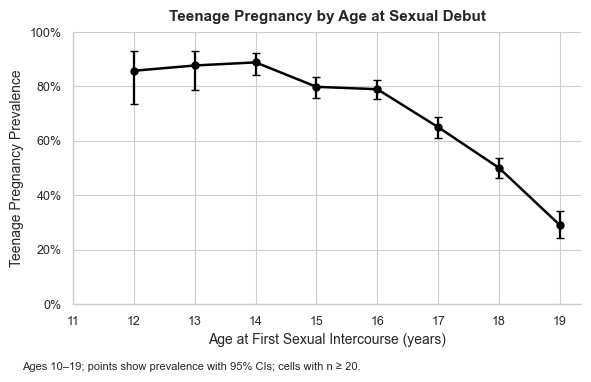

In [20]:
# Group by sex age year
gb = (cc.groupby('sex_age', as_index=False)
        .agg(n=('ado_preg', 'size'),
             cases=('ado_preg', 'sum')))

# Keep stable cells
gb = gb[gb['n'] >= MIN_N].copy()

# Prevalence + Wilson 95% CI
gb['prev'] = gb['cases'] / gb['n']
ci = gb.apply(lambda r: pd.Series(wilson_ci(int(r['cases']), int(r['n'])),
                                  index=['ci_low','ci_high']), axis=1)
gb = pd.concat([gb, ci], axis=1)

# Percent formats
gb['prev_pct'] = (100 * gb['prev']).round(1)
gb['ci_low_pct'] = (100 * gb['ci_low']).round(1)
gb['ci_high_pct'] = (100 * gb['ci_high']).round(1)

# Sort & endpoints
gb = gb.sort_values('sex_age').reset_index(drop=True)
first_row = gb.iloc[0]
last_row  = gb.iloc[-1]


print("\nPrevalence of teenage pregnancy by age at first sex:")
print(gb[['sex_age','n','cases','prev_pct','ci_low_pct','ci_high_pct']].to_string(index=False))
print(f"Total number of cases: {cc.sex_age.shape}")
print("\nTrend endpoints:")
print(f"From {first_row['prev_pct']:.1f}% (95% CI {first_row['ci_low_pct']:.1f}, {first_row['ci_high_pct']:.1f}) "
      f"at age {int(first_row['sex_age'])}, "
      f"to {last_row['prev_pct']:.1f}% (95% CI {last_row['ci_low_pct']:.1f}, {last_row['ci_high_pct']:.1f}) "
      f"at age {int(last_row['sex_age'])}.")

# ---------------------------------------
# PLOT
# ---------------------------------------
y = gb['prev'].to_numpy()
yerr = np.vstack([y - gb['ci_low'].to_numpy(),
                  gb['ci_high'].to_numpy() - y])
x = gb['sex_age'].to_numpy()

plt.figure(figsize=FIGSIZE)
ax = plt.gca()

ax.errorbar(x, y, yerr=yerr, fmt='o-', linewidth=LINEWIDTH, markersize=MARKERSIZE,
            capsize=CAPSIZE, elinewidth=LINEWIDTH*0.9, ecolor='black', color='black')

ax.set_title("Teenage Pregnancy by Age at Sexual Debut", fontsize=FONTSIZE+1, weight='bold', pad=8)
ax.set_xlabel("Age at First Sexual Intercourse (years)", fontsize=FONTSIZE)
ax.set_ylabel("Teenage Pregnancy Prevalence", fontsize=FONTSIZE)
ax.yaxis.set_major_formatter(PercentFormatter(1, decimals=0))
ax.set_ylim(0.0, 1.0)
ax.set_xticks(np.arange(11, 20, 1))
ax.tick_params(labelsize=FONTSIZE-1)

for spine in ("top", "right"):
    ax.spines[spine].set_visible(False)

note = f"Ages 10–19; points show prevalence with 95% CIs; cells with n ≥ {MIN_N}."
ax.text(-0.1, -0.25, note, transform=ax.transAxes, fontsize=FONTSIZE-2, va='bottom')

plt.tight_layout()
plt.savefig("./results/teen_preg_by_debut_age.png", dpi=400, bbox_inches="tight")
plt.show()

## Time to pregnancy after sexual debut

The first figure shows the mean years from debut to first pregnancy by age at sexual debut (10–19). A shorter interval at later debut ages does not imply later debut causes faster pregnancy. It mainly reflects exposure time and design truncation (teen window closes at ~20), not a biological acceleration.

The dumbbell figure shows for each debut age, the median age at first pregnancy clusters within the overall IQR of pregnancy ages (16–19). This shows that, regardless of when sexual debut occurs, first pregnancies tend to occur in mid–late adolescence.

Note that ages 18–19 have mechanically short intervals when restricting to teen pregnancies (right-truncation).

Social factors (e.g., marriage/cohabitation, schooling completion) may also align pregnancies to 16–19, but we treat these as plausible correlates, not causal claims.

SAMPLE COUNTS
* Cases (initiated ≤19 & pregnant ≤19): 1,925
* Controls (initiated ≤19, no teen preg, age ≥20): 1,040

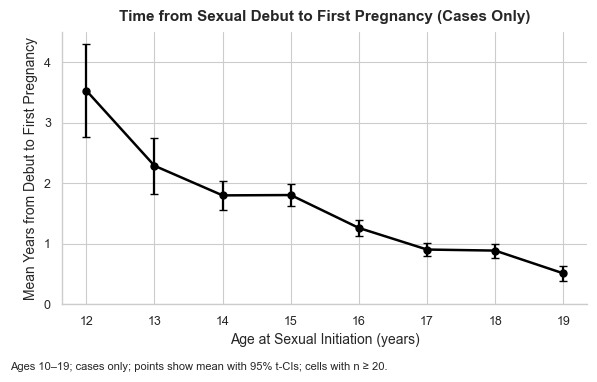

 sex_age_year   n  mean  ci_low  ci_high
           12  47  3.53    2.76     4.31
           13  73  2.29    1.83     2.75
           14 212  1.80    1.56     2.04
           15 355  1.80    1.62     1.99
           16 457  1.26    1.13     1.39
           17 444  0.90    0.79     1.01
           18 446  0.88    0.77     1.00
           19 150  0.51    0.38     0.63


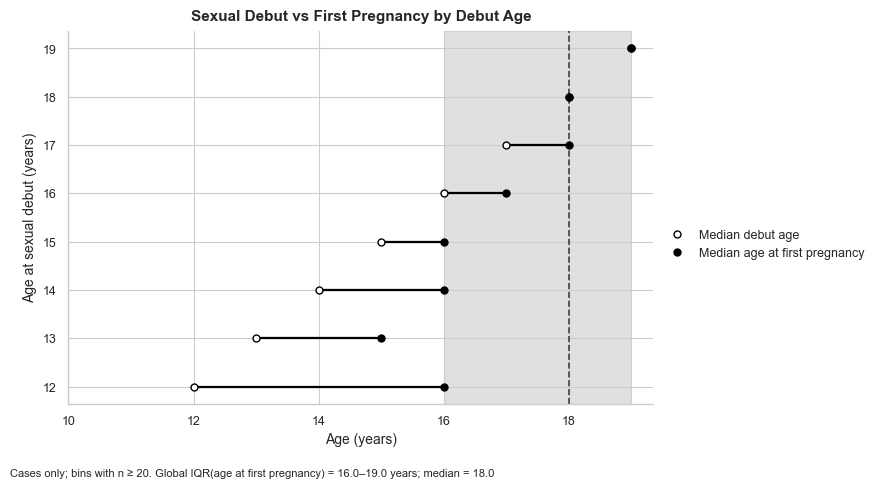

 sex_age_year   n  debut_med  preg_med
           12  49      12.00     16.00
           13  81      13.00     15.00
           14 232      14.00     16.00
           15 406      15.00     16.00
           16 541      16.00     17.00
           17 611      17.00     18.00
           18 682      18.00     18.00
           19 328      19.00     19.00


In [22]:
c = cc.copy()
c['sex_age_year'] = c['sex_age'].round().astype(int)
c['time_to_preg'] = c['age_preg'].astype(float) - c['sex_age'].astype(float)

# ---------------------------------------
# PLOT : mean_time_to_preg_by_debut_age_errorbars
# ---------------------------------------

# Per-age summary with t-based 95% CI
summary = (
    c.groupby('sex_age_year')['time_to_preg']
         .agg(n='count',
              mean='mean',
              sd=lambda x: x.std(ddof=1))
         .reset_index()
)

summary['se'] = summary['sd'] / np.sqrt(summary['n'])
summary['tcrit'] = 1.96
summary['ci_low']  = summary['mean'] - summary['tcrit'] * summary['se']
summary['ci_high'] = summary['mean'] + summary['tcrit'] * summary['se']

plot_df = summary[(summary['sex_age_year'] >= 10) & (summary['sex_age_year'] <= 19) & (summary['n'] >= MIN_N)] \
          .sort_values('sex_age_year').copy()

x = plot_df['sex_age_year'].to_numpy()
y = plot_df['mean'].to_numpy()
yerr = np.vstack([y - plot_df['ci_low'].to_numpy(),
                  plot_df['ci_high'].to_numpy() - y])

plt.figure(figsize=FIGSIZE)
ax = plt.gca()

# Error bar
ax.errorbar(
    x, y, yerr=yerr,
    fmt='o-', color='black', ecolor='black',
    linewidth=LINEWIDTH, markersize=MARKERSIZE,
    capsize=CAPSIZE, elinewidth=LINEWIDTH*0.9
)

# Label
ax.set_xlabel("Age at Sexual Initiation (years)", fontsize=FONTSIZE)
ax.set_ylabel("Mean Years from Debut to First Pregnancy", fontsize=FONTSIZE)
ax.set_xticks(np.arange(12, 20, 1))
ax.xaxis.set_major_locator(MaxNLocator(integer=True))
ax.tick_params(labelsize=FONTSIZE-1)
ax.set_ylim(bottom=0)  # start at 0 to avoid exaggeration

# Spine
for spine in ("top", "right"):
    ax.spines[spine].set_visible(False)

# Note
note = f"Ages 10–19; cases only; points show mean with 95% t-CIs; cells with n ≥ {MIN_N}."
ax.text(-0.1, -0.25, note, transform=ax.transAxes, fontsize=FONTSIZE-2, va='bottom')

# Show
ax.set_title("Time from Sexual Debut to First Pregnancy (Cases Only)", fontsize=FONTSIZE+1, weight='bold', pad=8)
plt.tight_layout()
plt.savefig("./results/mean_time_to_preg_by_debut_age_errorbars.png", dpi=400)
plt.show()

# Table shown in the figure
print(plot_df[['sex_age_year','n','mean','ci_low','ci_high']].round(2).to_string(index=False))

# ---------------------------------------
# PLOT : dumbbell_debut_vs_preg_GLOBAL_IQR
# ---------------------------------------

# Per-age medians for debut and pregnancy
summary = (
    c.groupby('sex_age_year')
         .agg(n=('age_preg','size'),
              debut_med=('sex_age','median'),
              preg_med =('age_preg','median'))
         .reset_index()
         .sort_values('sex_age_year')
)

# Keep stable bins
plot_df = summary[(summary['sex_age_year'].between(10,19)) & (summary['n'] >= MIN_N)].copy()
ypos = np.arange(len(plot_df))

# GLOBAL IQR band on the same population
ages_to_keep = set(plot_df['sex_age_year'].tolist())
used_rows = c[c['sex_age_year'].isin(ages_to_keep)].copy()

q1 = used_rows['age_preg'].quantile(0.25)
q3 = used_rows['age_preg'].quantile(0.75)
med_all = used_rows['age_preg'].median()

plt.figure(figsize=(9.0, 5.0))
ax = plt.gca()

for yi, a, b in zip(ypos, plot_df['debut_med'], plot_df['preg_med']):
    ax.hlines(yi, xmin=a, xmax=b, color='black', linewidth=LINEWIDTH*0.9)
ax.plot(plot_df['debut_med'], ypos, 'o', mfc='white', mec='black', ms=MARKERSIZE, label='Median debut age')
ax.plot(plot_df['preg_med'],  ypos, 'o', mfc='black',  mec='black', ms=MARKERSIZE, label='Median age at first pregnancy')

# Axes
ax.axvspan(q1, q3, alpha=0.12, color='black', zorder=0)
ax.axvline(med_all, linestyle='--', linewidth=1.2, color='black', alpha=0.7)

# Labels
ax.set_title("Sexual Debut vs First Pregnancy by Debut Age", fontsize=FONTSIZE+1, weight='bold', pad=8)
ax.set_yticks(ypos)
ax.set_yticklabels(plot_df['sex_age_year'].astype(int))
ax.set_ylabel("Age at sexual debut (years)", fontsize=FONTSIZE)
ax.set_xlabel("Age (years)", fontsize=FONTSIZE)
ax.set_xlim(left=10)
ax.tick_params(labelsize=FONTSIZE-1)

# Spine
for spine in ("top","right"):
    ax.spines[spine].set_visible(False)

# Legend + note
band_txt = f"Global IQR(age at first pregnancy) = {q1:.1f}–{q3:.1f} years; median = {med_all:.1f}"
ax.legend(frameon=False, fontsize=FONTSIZE-1, bbox_to_anchor=(1, 0.5))
ax.text(-0.1, -0.2,
        f"Cases only; bins with n ≥ {MIN_N}. {band_txt}" + (" (teen pregnancies only)" if TEEN_ONLY else ""),
        transform=ax.transAxes, fontsize=FONTSIZE-2, va='bottom')

# Show
plt.tight_layout()
plt.savefig("./results/dumbbell_debut_vs_preg_GLOBAL_IQR.png", dpi=400)
plt.show()

# Table shown in the figure
print(plot_df[['sex_age_year','n','debut_med', 'preg_med']].round(2).to_string(index=False))

## KM-based cumulative incidence by debut age

KM needs the full risk set of initiators and then censors those who don’t have a teen pregnancy by the end of follow-up (age 20 here).<br>
So here we include all girls that have initiated even if they are still in the risk period. Those who are past the risk period are censored up to 20 years.

SAMPLE COUNTS
* Cases    (initiated ≤19 & pregnant ≤19): 1,925
* Controls (initiated ≤19, no teen preg, irrespective of current age): 2,136

Within 1 year: 35.3% (95% CI 33.8, 36.8)
Within 2 years: 44.8% (95% CI 43.1, 46.4)
 sex_age_year   n  inc_1y_pct  inc_1y_lo  inc_1y_hi  inc_2y_pct  inc_2y_lo  inc_2y_hi
           10  29        0.00       0.00       0.00        3.60       0.50      22.80
           11  21        9.50       2.50      33.00        9.50       2.50      33.00
           12  70       21.40      13.50      33.00       26.10      17.30      38.10
           13 122       25.60      18.80      34.40       37.50      29.30      47.20
           14 328       31.10      26.40      36.40       47.80      42.30      53.60
           15 584       32.40      28.70      36.40       45.30      41.20      49.60
           16 792       37.70      34.40      41.20       51.30      47.70      55.00
           17 904       38.70      35.60      42.00       47.70      44.20      51.30
           18 854       41.50      38.20      45.00       41.50      38.20      45.00
           19 352       27.00      22.70      32.00      

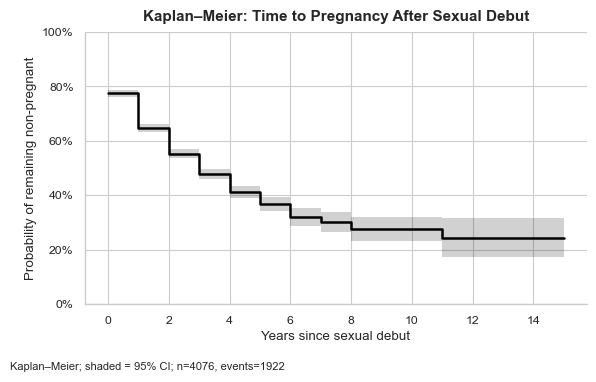

In [24]:
# Keep initiators in teen window only
km = df_raw[df_raw['sex_age'].le(19)].copy()
km['sex_age_year'] = np.floor(km['sex_age']).astype(int)

# Event time (if teen pregnancy) or censoring time (to min(20, interview age))
# 1) Event: teen pregnancy
km['event']   = (km['ado_preg'] == 1).astype(int)
km['t_event'] = km['age_preg'] - km['sex_age']

# 2) Censoring: no teen pregnancy by interview or by 20
#    If event==0, use min(20, age_completed) - sex_age
km['t_cens'] = np.minimum(20.0, km['age_completed']) - km['sex_age']

# Final analysis time = event time if event==1 else censor time
km['duration'] = np.where(km['event'].eq(1), km['t_event'], km['t_cens'])

# Guardrails: drop negatives / missing durations
km = km[np.isfinite(km['duration']) & (km['duration'] >= 0)].copy()

# Fit overall KM
kmf_overall = KaplanMeierFitter()
kmf_overall.fit(km['duration'], event_observed=km['event'])

def km_incidence_at(kmf, t):
    sf = kmf.survival_function_
    ci = kmf.confidence_interval_
    sf_col  = sf.columns[0]
    low_col = [c for c in ci.columns if 'lower' in c.lower()][0]
    high_col= [c for c in ci.columns if 'upper' in c.lower()][0]
    i_sf = max(0, min(len(sf)-1, sf.index.searchsorted(t, side='right') - 1))
    i_ci = max(0, min(len(ci)-1, ci.index.searchsorted(t, side='right') - 1))
    S, S_lo, S_hi = float(sf.iloc[i_sf][sf_col]), float(ci.iloc[i_ci][low_col]), float(ci.iloc[i_ci][high_col])
    return 1 - S, 1 - S_hi, 1 - S_lo  # invert CI correctly

inc1, lo1, hi1 = km_incidence_at(kmf_overall, 1)
inc2, lo2, hi2 = km_incidence_at(kmf_overall, 2)
print(f"Within 1 year: {inc1*100:.1f}% (95% CI {lo1*100:.1f}, {hi1*100:.1f})")
print(f"Within 2 years: {inc2*100:.1f}% (95% CI {lo2*100:.1f}, {hi2*100:.1f})")

# Per debut-age
rows = []
for age, g in km.groupby('sex_age_year'):
    if 10 <= age <= 19 and len(g) >= 20:  # stability rule
        kmf = KaplanMeierFitter().fit(g['duration'], event_observed=g['event'])
        a1, a1_lo, a1_hi = km_incidence_at(kmf, 1)
        a2, a2_lo, a2_hi = km_incidence_at(kmf, 2)
        rows.append(dict(
            sex_age_year=age, n=len(g),
            inc_1y_pct=round(a1*100,1), inc_1y_lo=round(a1_lo*100,1), inc_1y_hi=round(a1_hi*100,1),
            inc_2y_pct=round(a2*100,1), inc_2y_lo=round(a2_lo*100,1), inc_2y_hi=round(a2_hi*100,1),
        ))
tab_teen = pd.DataFrame(rows).sort_values('sex_age_year')
print(tab_teen.to_string(index=False))

# Check survival at 1 & 2 directly
print("Overall survival at 1 year:", float(kmf_overall.survival_function_at_times(1).values[0]))
print("Overall survival at 2 years:", float(kmf_overall.survival_function_at_times(2).values[0]))

# ---------------------------------------
# PLOT : km_time_to_preg
# ---------------------------------------
sf = kmf_overall.survival_function_
ci = kmf_overall.confidence_interval_

sf_col  = sf.columns[0]
low_col = [c for c in ci.columns if 'lower' in c.lower()][0]
high_col= [c for c in ci.columns if 'upper' in c.lower()][0]

# Align CI to SF timeline and convert to arrays
t  = sf.index.values.astype(float)
lo = ci[low_col].reindex(sf.index, method='pad').values.astype(float)
hi = ci[high_col].reindex(sf.index, method='pad').values.astype(float)
s  = sf[sf_col].values.astype(float)

# Remove any NaNs that could break fill_between
m = np.isfinite(t) & np.isfinite(lo) & np.isfinite(hi) & np.isfinite(s)
t, lo, hi, s = t[m], lo[m], hi[m], s[m]

fig, ax = plt.subplots(figsize=(6,4))

# 95% CI shaded band (behind the step)
ax.fill_between(t, lo, hi, step='post', alpha=0.18, color='black', linewidth=0, zorder=1)

# KM step line
ax.step(t, s, where='post', linewidth=1.8, color='black', zorder=2)

ax.set_title("Kaplan–Meier: Time to Pregnancy After Sexual Debut", fontsize=FONTSIZE+1, weight='bold', pad=8)
ax.set_xlabel("Years since sexual debut")
ax.set_ylabel("Probability of remaining non-pregnant")
ax.yaxis.set_major_formatter(PercentFormatter(1, 0))
ax.set_ylim(0, 1)
for spine in ("top","right"): ax.spines[spine].set_visible(False)
ax.text(-0.15, -0.25, f"Kaplan–Meier; shaded = 95% CI; n={len(km)}, events={int(km['event'].sum())}",
        transform=ax.transAxes, fontsize=8, va='bottom')

plt.tight_layout()
plt.savefig("./results/km_time_to_preg.png", dpi=400, bbox_inches="tight")
plt.show()

## Logistic Regression

SAMPLE COUNTS
* Cases (initiated ≤19 & pregnant ≤19): 1,925
* Controls (initiated ≤19, no teen preg, age ≥20): 1,040
* Total after dropping NAs : 2,768

*adjusting for marriage*
It’s very likely on the causal pathway that earlier debut → earlier/greater chance of marriage → higher pregnancy risk. Adjusting for it would attenuate the effect you want to estimate.

RESULTS<br>
Per-year delay: aOR = 0.61 p<0.001 -> After accounting for partner type and willingness/avoidance indicators, later sexual debut remains protective—about 39% lower odds per year.

In [26]:
# Keep initiators with complete data on these covariates
dfm = cc[['ado_preg','sex_age','will_sex_binary','do_anything_binary','person_sex_group']].dropna().copy()

# Dummies for partner at first sex (baseline = first category alphabetically)
dfm['person_sex_group'] = pd.Categorical(dfm['person_sex_group'])
partner_dummies = pd.get_dummies(dfm['person_sex_group'], prefix='partner', drop_first=True, dtype=float)

# Outcome & predictors
y = dfm['ado_preg'].astype(int)
X = pd.concat(
    [dfm[['sex_age','will_sex_binary','do_anything_binary']].astype(float), partner_dummies],
    axis=1
)
X = sm.add_constant(X, has_constant='add')

# Fit
m = sm.Logit(y, X).fit(disp=False)
# Robust SEs
try:
    m = m.get_robustcov_results(cov_type='HC1')
except Exception:
    pass

print(m.summary())

b, (lo, hi) = m.params['sex_age'], m.conf_int().loc['sex_age']
print(f"Age of initiation (+1): aOR {np.exp(b):.3f} (95% CI {np.exp(lo):.3f}, {np.exp(hi):.3f})")

                           Logit Regression Results                           
Dep. Variable:               ado_preg   No. Observations:                 2768
Model:                          Logit   Df Residuals:                     2762
Method:                           MLE   Df Model:                            5
Date:                Thu, 02 Oct 2025   Pseudo R-squ.:                  0.1565
Time:                        14:38:16   Log-Likelihood:                -1515.9
converged:                       True   LL-Null:                       -1797.2
Covariance Type:            nonrobust   LLR p-value:                2.558e-119
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                  8.7731      0.525     16.712      0.000       7.744       9.802
sex_age               -0.4827      0.031    -15.729      0.000      -0.543      -0.423
will_sex_binary     

# Teenage Pregnancy and School Dropout

**Does teenage pregnancy increase school dropout risk?**
* Descriptive: What is the prevalence of teen pregnancy by schooling status (ages 10–19 at interview)?
* Modelling: What is the association between schooling exposure and teen pregnancy risk during adolescence, adjusting for time-at-risk and marriage timing?

## Descriptive snapshot (prevalence by current schooling status)

**What is the prevalence of teen pregnancy by schooling status, among girls aged 10 - 19 at the time of the interview?**

SAMPLE COUNTS
* Cases (age completed ≤19 & pregnant ≤19): 594
* Controls (age completed ≤19 & NOT pregnant ≤19): 4,127

*Note.* This is associational and partly reflects selection (older teens are more likely to be out of school and also to have had time to become pregnant).

*Note.* Since schooling is measured at interview (not at the time of pregnancy), the safest way for this cases-only table is to combine “in_school” + “completed_USE” into a single bucket (call it “in-school/completed”), so we don’t imply that girls who later finished school were out of school at the time of pregnancy.

In [29]:
# Sample filtering
d = df_raw.copy()

# Keep rows with a valid 3-level schooling status only
VALID_STATUS = ['in_school', 'completed_lower_secondary', 'dropped_out']
d = d[d['school_complete3_lbl'].isin(VALID_STATUS)].copy()

# Define cases/controls within the 10–19 interview window
cases    = d[(d['age_completed'].le(19)) & (d['ado_preg'] == 1)].copy()
controls = d[(d['age_completed'].le(19)) & (d['ado_preg'] == 0)].copy()
excluded = d[(d['age_completed'].ge(20))].copy()

# Case–control frame
cc = pd.concat([cases, controls], axis=0).copy()
cc['case'] = (cc['ado_preg'] == 1).astype(int)

print("SAMPLE COUNTS")
print(f"Cases    (age_completed ≤19 & pregnant ≤19): {len(cases):,}")
print(f"Controls (age_completed ≤19 & NOT pregnant ≤19): {len(controls):,}")
print(f"Excluded (age_completed >19): {len(excluded):,}")
print(f"Total rows: {len(d):,}  |  Sum: {len(cases)+len(controls)+len(excluded):,}")

SAMPLE COUNTS
Cases    (age_completed ≤19 & pregnant ≤19): 594
Controls (age_completed ≤19 & NOT pregnant ≤19): 4,127
Excluded (age_completed >19): 3,104
Total rows: 7,825  |  Sum: 7,825


In [30]:
# ===============================
# TABLE A — PREVALENCE & 95% CI BY SCHOOL STATUS (within cc)
# ===============================
tab_prev = (cc.groupby('school_complete3_lbl', as_index=False)
              .agg(n=('ado_preg','size'),
                   cases=('ado_preg','sum'))
              .sort_values('school_complete3_lbl'))

tab_prev = add_prev_ci(tab_prev, num='cases', den='n')  # your function

print("\nTeen pregnancy prevalence by schooling status (≤19 cohort):")
tab_prev[['school_complete3_lbl','n','cases','prev_pct','ci_low_pct','ci_high_pct']].to_string(index=False)
tab_prev


Teen pregnancy prevalence by schooling status (≤19 cohort):


,school_complete3_lbl,n,cases,ci_low,ci_high,prev_pct,ci_low_pct,ci_high_pct
0,completed_lower_secondary,476,144,0.26,0.35,30.30,26.30,34.50
1,dropped_out,1452,417,0.26,0.31,28.70,26.50,31.10
2,in_school,2793,33,0.01,0.02,1.20,0.80,1.70


In [31]:
# ===============================
# TABLE B — BREAKDOWN OF SCHOOL STATUS BY TEEN-PREG OUTCOME (row-wise %)
# ===============================
# Labels for rows
cc['ado_preg_label'] = cc['ado_preg'].map({0: 'No teen pregnancy', 1: 'Teen pregnancy'})

status_order = [s for s in VALID_STATUS if s in cc['school_complete3_lbl'].unique()]

cnt = (pd.crosstab(cc['ado_preg_label'], cc['school_complete3_lbl'])
         .reindex(index=['No teen pregnancy','Teen pregnancy'])
         .reindex(columns=status_order, fill_value=0)
         .astype('Int64'))

row_tot = cnt.sum(axis=1).replace(0, np.nan)
pct = (cnt.div(row_tot, axis=0) * 100).round(1)

table_breakdown = pd.concat(
    [cnt.add_suffix(' (n)'), pct.add_suffix(' (%)')],
    axis=1
)

print("\nSchooling distribution by teen-pregnancy status (row-wise %):")
table_breakdown.to_string()
table_breakdown


Schooling distribution by teen-pregnancy status (row-wise %):


school_complete3_lbl,in_school (n),completed_lower_secondary (n),dropped_out (n),in_school (%),completed_lower_secondary (%),dropped_out (%)
ado_preg_label,,,,,,
No teen pregnancy,2760,332,1035,66.90,8.00,25.10
Teen pregnancy,33,144,417,5.60,24.20,70.20


**Cases-only: Age of pregnancy × schooling status for girls 10 - 19 at interview**

In [33]:
# ===============================
# TABLE C — CASES ONLY: AGE AT FIRST PREGNANCY × SCHOOL STATUS (row-wise %)
# ===============================
cases = cases.copy()
cases = cases[cases['age_preg'].notna()]  # ensure age_preg exists
cases['age_preg_year'] = cases['age_preg'].round().astype(int)

ages = pd.Index(range(10, 20), name='age_preg_year')

cnt_age = (cases.groupby(['age_preg_year', 'school_complete3_lbl'])
                 .size()
                 .unstack('school_complete3_lbl')
                 .reindex(ages, fill_value=0))

# ensure the 3 columns exist and are ordered
for col in VALID_STATUS:
    if col not in cnt_age.columns:
        cnt_age[col] = 0
cnt_age = cnt_age[VALID_STATUS].astype('Int64')

# totals + row-wise %
cnt_age['total (n)'] = cnt_age.sum(axis=1).astype('Int64')
den_age = cnt_age['total (n)'].astype('float64').replace(0, np.nan)
pct_age = (cnt_age[VALID_STATUS].astype('float64').div(den_age, axis=0) * 100).round(1).fillna(0.0)

table_age = pd.DataFrame({
    'in-school (n)':                 cnt_age['in_school'],
    'in-school (%)':                 pct_age['in_school'],
    'completed lower secondary (n)': cnt_age['completed_lower_secondary'],
    'completed lower secondary (%)': pct_age['completed_lower_secondary'],
    'dropped-out (n)':               cnt_age['dropped_out'],
    'dropped-out (%)':               pct_age['dropped_out'],
    'total (n)':                     cnt_age['total (n)'],
    'total (%)':                     100.0,
})

print("\nColumn totals (cases only):")
print(f"Total in-school: {int(table_age['in-school (n)'].sum())}")
print(f"Completed lower secondary: {int(table_age['completed lower secondary (n)'].sum())}")
print(f"Total dropped-out: {int(table_age['dropped-out (n)'].sum())}")
print(f"Total: {int(table_age['total (n)'].sum())}")

print("\nCASES ONLY — Exact age at first pregnancy × School status (row-wise %):")
table_age.to_string()
table_age


Column totals (cases only):
Total in-school: 33
Completed lower secondary: 144
Total dropped-out: 417
Total: 594

CASES ONLY — Exact age at first pregnancy × School status (row-wise %):


,in-school (n),in-school (%),completed lower secondary (n),completed lower secondary (%),dropped-out (n),dropped-out (%),total (n),total (%)
age_preg_year,,,,,,,,
10,0,0.00,0,0.00,0,0.00,0,100.00
11,<NA>,0.00,<NA>,0.00,1,100.00,1,100.00
12,<NA>,0.00,<NA>,0.00,5,100.00,5,100.00
13,<NA>,0.00,<NA>,0.00,6,100.00,6,100.00
14,3,10.00,2,6.70,25,83.30,30,100.00
15,2,3.00,9,13.60,55,83.30,66,100.00
16,5,3.40,34,23.40,106,73.10,145,100.00
17,14,7.80,47,26.10,119,66.10,180,100.00
18,9,6.90,38,29.20,83,63.80,130,100.00


**Cases-only: By education pool (≤UPE / USE / USE+) × schooling status for girls 10 - 19 at interview**

In [35]:
# ===============================
# TABLE C — CASES ONLY: SCHOOL LEVEL AT FIRST PREGNANCY × SCHOOL STATUS (row-wise %)
# ===============================

# Pool highest education:
pool_map = {
    'less_than_UPE': '≤UPE',
    'UPE':            'UPE',
    'USE':            'USE',
    'higher_than_USE':'USE+',
    'Unknown': 'Unknown'
}
edu = cases['edu_bucket_highest'].astype('string')
mapped = edu.map(pool_map)
edu_order = ['≤UPE', 'UPE', 'USE', 'USE+', 'Unknown']
cases['edu_pool'] = pd.Categorical(mapped, categories=edu_order, ordered=True)
cases_edu = cases[cases['edu_pool'].notna()].copy()

cnt_edu = (cases_edu.groupby(['edu_pool','school_complete3_lbl'])
                    .size()
                    .unstack('school_complete3_lbl')
                    .reindex(index=edu_order, fill_value=0))

for col in VALID_STATUS:
    if col not in cnt_edu.columns:
        cnt_edu[col] = 0
cnt_edu = cnt_edu[VALID_STATUS].astype('Int64')

cnt_edu['total (n)'] = cnt_edu.sum(axis=1).astype('Int64')
den_edu = cnt_edu['total (n)'].astype('float64').replace(0, np.nan)
pct_edu = (cnt_edu[VALID_STATUS].astype('float64').div(den_edu, axis=0) * 100).round(1).fillna(0.0)

table_edu = pd.DataFrame({
    'in-school (n)':                 cnt_edu['in_school'],
    'in-school (%)':                 pct_edu['in_school'],
    'completed lower secondary (n)': cnt_edu['completed_lower_secondary'],
    'completed lower secondary (%)': pct_edu['completed_lower_secondary'],
    'dropped-out (n)':               cnt_edu['dropped_out'],
    'dropped-out (%)':               pct_edu['dropped_out'],
    'total (n)':                     cnt_edu['total (n)'],
    'total (%)':                     100.0,
})

print(f"Total in-school: {table_edu['in-school (n)'].sum()}")
print(f"Complete school: {table_edu['completed lower secondary (n)'].sum()}")
print(f"Total dropped out: {table_edu['dropped-out (n)'].sum()}")
print(f"Total: {table_edu['total (n)'].sum()}")
table_edu.to_string(index=False)
table_edu

Total in-school: 33
Complete school: 144
Total dropped out: 417
Total: 594


,in-school (n),in-school (%),completed lower secondary (n),completed lower secondary (%),dropped-out (n),dropped-out (%),total (n),total (%)
edu_pool,,,,,,,,
≤UPE,1,50.00,0,0.00,1,50.00,2,100.00
UPE,17,3.90,0,0.00,416,96.10,433,100.00
USE,4,2.80,140,97.20,0,0.00,144,100.00
USE+,11,73.30,4,26.70,0,0.00,15,100.00
Unknown,0,0.00,0,0.00,0,0.00,0,100.00


## Logistic Regression

**Estimate the association between schooling exposure and teen pregnancy risk during adolescence, adjusting for time-at-risk and marriage timing.**

SAMPLE COUNTS
* Cases (initiated ≤19 & pregnant ≤19): 1,925
* Controls (initiated ≤19, no teen preg, age ≥20): 1,040 -> outside of risk window
* Total after dropping NAs : 2,192

*Deriving “years of schooling”*

When a direct count of years completed (years_school) was available, we used it as reported (after coercing to numeric and treating non-numeric entries as missing).
If years_school was unavailable, we imputed an approximate years-of-schooling measure from the respondent’s highest level completed (level_scol_recode) using the following mapping, consistent with the Ugandan system and our analytic need to place respondents on a single continuous scale:

* level_scol_recode ∈ {2, 3} → 7 years (completed primary/UPE)
* level_scol_recode ∈ {4, 5} → 11 years (completed lower secondary / O-Level, i.e., USE)
* level_scol_recode = 6 → 13 years (completed upper secondary / A-Level)
* level_scol_recode ∈ {7, 8, 9} → 14 years (any tertiary or higher)

All other or invalid level_scol_recode values were left missing. This produces a conservative, monotonic approximation that preserves ordering across schooling milestones while minimizing arbitrary precision beyond level boundaries.

*Covariates*

Not controlling for willingness, partner type, or contraception in your primary schooling model. These are very likely post-exposure mediators (schooling → later debut / different partners / more prevention → lower pregnancy risk). Adjusting for them would bias the schooling effect toward the null.

RESULTS<br>
Years of schooling (+1): aOR ~0.81 (95% CI ~0.77–0.86) → about 19% lower odds of a teen pregnancy per additional year of schooling, controlling for time-at-risk (teen sexual exposure), age at interview (centered), and marriage by 19.

In [37]:
# --- prep & filtering ---
d = df_raw.copy()

cases = d[(d['sex_age'] <= 19) & (d['ado_preg'] == 1)]
controls = d[(d['sex_age'] <= 19) & (d['ado_preg'] == 0) & (d['age_completed'] >= 20)]

cc = pd.concat([cases, controls], axis=0).copy()

# --- outcome ---
cc['ado_preg'] = cc['ado_preg'].astype(int)

# --- schooling ---


# --- risk time (teen exposure) ---
risk_end = np.minimum(19.0, cc['age_completed'])
cc['risk_time'] = np.where(cc['sex_age'].notna(),
                           np.clip(risk_end - cc['sex_age'], 0, None),
                           0.0)

# --- center covariates ---
cc['years_school_c']   = cc['years_school']   - cc['years_school'].mean()
cc['age_completed_c']  = cc['age_completed']  - cc['age_completed'].mean()

dm = cc[['ado_preg','years_school_c','risk_time','age_completed_c','married_by19']].dropna()
y  = dm['ado_preg'].astype(int)
X  = sm.add_constant(dm.drop(columns=['ado_preg']).astype(float))

m = sm.Logit(y, X).fit(disp=False)
print(m.summary())

b, (lo, hi) = m.params['years_school_c'], m.conf_int().loc['years_school_c']
print(f"Years of schooling (+1): aOR {np.exp(b):.3f} (95% CI {np.exp(lo):.3f}, {np.exp(hi):.3f})")

                           Logit Regression Results                           
Dep. Variable:               ado_preg   No. Observations:                 2965
Model:                          Logit   Df Residuals:                     2960
Method:                           MLE   Df Model:                            4
Date:                Thu, 02 Oct 2025   Pseudo R-squ.:                  0.3717
Time:                        14:38:16   Log-Likelihood:                -1207.1
converged:                       True   LL-Null:                       -1921.1
Covariance Type:            nonrobust   LLR p-value:                5.837e-308
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
const              -0.6779      0.089     -7.635      0.000      -0.852      -0.504
years_school_c     -0.2307      0.018    -12.930      0.000      -0.266      -0.196
risk_time           0.2349      

# Marriage and Teenage Pregnancy

**What is the effect of early marriage on pregnancy outcomes among teenage girls?**

* Descriptive: Among girls married at m, what % ever had a teen pregnancy (≤19)?
* Modelling: What is the association between teen marriage and teen pregnancy?

## Descriptive snapshot (prevelance by teen marriage)

Given how tight the marriage↔teen-pregnancy link is among those married at age m, the clearer story is the age-t snapshot: compare girls married by age t vs not married by age t, with both groups drawn from girls who were actually observed through age t (i.e., age_completed >= t).

In [40]:
AGES = range(10, 20)

rows = []
for t in AGES:
    # only girls observed through age t
    pool = df_raw[df_raw['age_completed'] >= t].copy()
    if pool.empty:
        continue

    # status at age t
    pool['married_by_t']    = pool['age_marry'].notna() & (pool['age_marry'] <= t)
    pool['ever_preg_by_t']  = (pool['ado_preg'].eq(1) &
                               pool['age_preg'].notna() &
                               (pool['age_preg'] <= t)).astype(int)

    # married-by-t
    g1 = pool[pool['married_by_t']]
    n1 = len(g1); k1 = int(g1['ever_preg_by_t'].sum())
    lo1, hi1 = wilson_ci(k1, n1) if n1 else (float('nan'), float('nan'))

    # not married-by-t
    g0 = pool[~pool['married_by_t']]
    n0 = len(g0); k0 = int(g0['ever_preg_by_t'].sum())
    lo0, hi0 = wilson_ci(k0, n0) if n0 else (float('nan'), float('nan'))

    rows.append({
        'age_t': t,
        'married_n': n1, 'married_prev': k1/n1 if n1 else float('nan'),
        'married_ci_low': lo1, 'married_ci_high': hi1,
        'unmarried_n': n0, 'unmarried_prev': k0/n0 if n0 else float('nan'),
        'unmarried_ci_low': lo0, 'unmarried_ci_high': hi0
    })

tab_by_status_at_age = pd.DataFrame(rows)

# Optional: keep ages where both groups have enough n
MIN_N = 20
stable = tab_by_status_at_age[(tab_by_status_at_age['married_n']   >= MIN_N) &
                              (tab_by_status_at_age['unmarried_n'] >= MIN_N)].copy()

# Example sentence for age 14:
t = 14
r = stable.loc[stable['age_t']==t].squeeze()
print(
    f"At age {t}, the prevalence of having ever been pregnant by that age was "
    f"{r['married_prev']*100:.1f}% (95% CI {r['married_ci_low']*100:.1f}, {r['married_ci_high']*100:.1f}) "
    f"among girls married by age {t}, versus "
    f"{r['unmarried_prev']*100:.1f}% (95% CI {r['unmarried_ci_low']*100:.1f}, {r['unmarried_ci_high']*100:.1f}) "
    f"among those not married by age {t}."
)

t = 19
r = stable.loc[stable['age_t']==t].squeeze()
print(
    f"At age {t}, the prevalence of having ever been pregnant by that age was "
    f"{r['married_prev']*100:.1f}% (95% CI {r['married_ci_low']*100:.1f}, {r['married_ci_high']*100:.1f}) "
    f"among girls married by age {t}, versus "
    f"{r['unmarried_prev']*100:.1f}% (95% CI {r['unmarried_ci_low']*100:.1f}, {r['unmarried_ci_high']*100:.1f}) "
    f"among those not married by age {t}."
)

At age 14, the prevalence of having ever been pregnant by that age was 46.9% (95% CI 36.4, 57.7) among girls married by age 14, versus 1.2% (95% CI 0.9, 1.4) among those not married by age 14.
At age 19, the prevalence of having ever been pregnant by that age was 91.3% (95% CI 89.4, 92.9) among girls married by age 19, versus 21.4% (95% CI 20.0, 22.9) among those not married by age 19.


**Exact age at first pregnancy × marital status at time of pregnancy [cases only]**

In [42]:
# --- TABLE: Exact age at first pregnancy × marital status at time of pregnancy [cases only] ---
cases = df_raw.copy()
cases    = cases[(cases['ado_preg'] == 1)]

# Marital status at time of first pregnancy:
# "Married before pregnancy" = married and age_marry <= age_preg
cases['married_before_preg'] = cases['age_marry'].notna() & (cases['age_marry'] <= cases['age_preg'])
cases['marital_at_preg'] = np.where(cases['married_before_preg'], 'Married before pregnancy', 'Not married before pregnancy')

# Exact age at first pregnancy (integer 10–19)
cases['age_preg_year'] = cases['age_preg'].round().astype(int)

# Count matrix
ages = pd.Index(range(10, 20), name='age_preg_year')
cnt = (
    cases.groupby(['age_preg_year','marital_at_preg'])
         .size()
         .unstack('marital_at_preg')
         .reindex(ages, fill_value=0)
)

# Ensure both columns are present and ordered
cols = ['Married before pregnancy', 'Not married before pregnancy']
for c in cols:
    if c not in cnt.columns: cnt[c] = 0
cnt = cnt[cols].astype('Int64')

# Totals
cnt['Total (n)'] = (cnt[cols].sum(axis=1)).astype('Int64')

# Row-wise % (horizontal: each age sums to 100)
den = cnt['Total (n)'].astype(float).replace(0, np.nan)
pct = (cnt[cols].astype(float).div(den, axis=0) * 100).round(1).fillna(0.0)

# Assemble pretty table
table = pd.DataFrame({
    'Married before pregnancy (n)':         cnt['Married before pregnancy'],
    'Married before pregnancy (%)':         pct['Married before pregnancy'],
    'Not married before pregnancy (n)':     cnt['Not married before pregnancy'],
    'Not married before pregnancy (%)':     pct['Not married before pregnancy'],
    'Total (n)':                            cnt['Total (n)'],
    'Total (%)':                            np.where(cnt['Total (n)']>0, 100.0, 0.0)
}, index=ages)

table.index.name = 'Exact age at first pregnancy'
table.to_string()

# Column totals for headers
n_married = int(cnt['Married before pregnancy'].sum())
n_not     = int(cnt['Not married before pregnancy'].sum())
N_total   = int(cnt['Total (n)'].sum())
print(f"Married before pregnancy (n={n_married}) | Not married before pregnancy (n={n_not}) | Total (N={N_total})")
table

Married before pregnancy (n=873) | Not married before pregnancy (n=1052) | Total (N=1925)


,Married before pregnancy (n),Married before pregnancy (%),Not married before pregnancy (n),Not married before pregnancy (%),Total (n),Total (%)
Exact age at first pregnancy,,,,,,
10,0,0.00,0,0.00,0,0.00
11,<NA>,0.00,2,100.00,2,100.00
12,4,33.30,8,66.70,12,100.00
13,7,29.20,17,70.80,24,100.00
14,25,28.70,62,71.30,87,100.00
15,67,42.40,91,57.60,158,100.00
16,139,42.20,190,57.80,329,100.00
17,198,45.40,238,54.60,436,100.00
18,266,49.30,274,50.70,540,100.00


## KM-based cumulative incidence by marriage age

among girls who marry at ages 10–19, how quickly do pregnancies occur before age 20?

SAMPLE: Girls married in 10–19 (age_marry between 10 and 19) and observed at/after marriage (age_completed >= age_marry) so the “clock start” is observed.

Within 1 year of marriage: 71.8% (95% CI 69.1, 74.4)
Within 2 years of marriage: 77.6% (95% CI 74.9, 80.2)
 marry_age   n  inc_1y_pct  inc_1y_lo  inc_1y_hi  inc_2y_pct  inc_2y_lo  inc_2y_hi
     14.00  42       76.20      62.60      87.70       89.40      77.70      96.50
     15.00 106       72.40      63.50      80.80       78.80      70.30      86.20
     16.00 190       75.10      68.60      81.10       87.20      81.80      91.70
     17.00 265       81.00      76.00      85.60       84.90      80.10      89.10
     18.00 324       76.80      71.90      81.30       76.80      71.90      81.30
     19.00 170       50.00      42.80      57.70       50.00      42.80      57.70


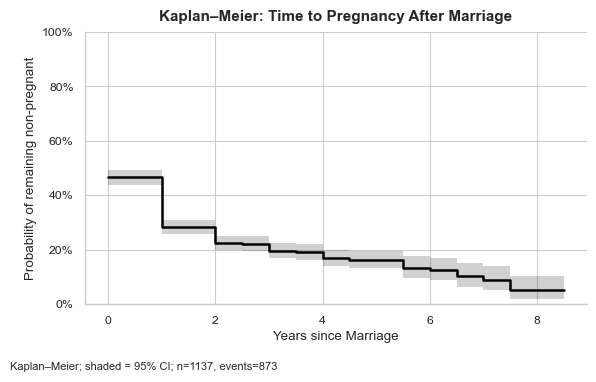

In [44]:
# --- KM: time to 1st pregnancy AFTER marriage, among girls married at 10–19 ---
km = df_raw.copy()

# 1) Keep marriages in teen window and ensure observed at/after marriage
km = km[km['age_marry'].between(10, 19)]
km = km[km['age_completed'].notna() & (km['age_completed'] >= km['age_marry'])]

# 2) Event: teen pregnancy that occurs AFTER marriage (and ≤19)
event_mask = km['age_preg'].notna() & (km['age_preg'] >= km['age_marry']) & (km['age_preg'] <= 19)
km['event']   = event_mask.astype(int)

# 3) Durations
#    - event time if event==1
#    - else censor at min(20, age_completed)
t_event = km['age_preg'] - km['age_marry']
t_cens  = np.minimum(20.0, km['age_completed']) - km['age_marry']
km['duration'] = np.where(km['event'].eq(1), t_event, t_cens)

# 4) Guardrails: finite and non-negative time
km = km[np.isfinite(km['duration']) & (km['duration'] >= 0)].copy()

# 5) Overall KM
kmf_overall = KaplanMeierFitter()
kmf_overall.fit(km['duration'], event_observed=km['event'])

def km_incidence_at(kmf, t):
    sf = kmf.survival_function_
    ci = kmf.confidence_interval_
    sf_col  = sf.columns[0]
    low_col = [c for c in ci.columns if 'lower' in c.lower()][0]
    high_col= [c for c in ci.columns if 'upper' in c.lower()][0]
    i_sf = max(0, min(len(sf)-1, sf.index.searchsorted(t, side='right') - 1))
    i_ci = max(0, min(len(ci)-1, ci.index.searchsorted(t, side='right') - 1))
    S, S_lo, S_hi = float(sf.iloc[i_sf][sf_col]), float(ci.iloc[i_ci][low_col]), float(ci.iloc[i_ci][high_col])
    return 1 - S, 1 - S_hi, 1 - S_lo  # invert CI

inc1, lo1, hi1 = km_incidence_at(kmf_overall, 1)
inc2, lo2, hi2 = km_incidence_at(kmf_overall, 2)
print(f"Within 1 year of marriage: {inc1*100:.1f}% (95% CI {lo1*100:.1f}, {hi1*100:.1f})")
print(f"Within 2 years of marriage: {inc2*100:.1f}% (95% CI {lo2*100:.1f}, {hi2*100:.1f})")

# 6) Stratify by exact age at marriage (stable cells only)
MIN_N = 20
rows = []
for m_age, g in km.groupby('age_marry'):
    if 10 <= m_age <= 19 and len(g) >= MIN_N:
        kmf = KaplanMeierFitter().fit(g['duration'], event_observed=g['event'])
        a1, a1_lo, a1_hi = km_incidence_at(kmf, 1)
        a2, a2_lo, a2_hi = km_incidence_at(kmf, 2)
        rows.append({
            'marry_age': m_age, 'n': len(g),
            'inc_1y_pct': round(a1*100,1), 'inc_1y_lo': round(a1_lo*100,1), 'inc_1y_hi': round(a1_hi*100,1),
            'inc_2y_pct': round(a2*100,1), 'inc_2y_lo': round(a2_lo*100,1), 'inc_2y_hi': round(a2_hi*100,1),
        })
tab_teen = pd.DataFrame(rows).sort_values('marry_age')
print(tab_teen.to_string(index=False))

# ---------------------------------------
# PLOT : km_time_to_preg
# ---------------------------------------
sf = kmf_overall.survival_function_
ci = kmf_overall.confidence_interval_

sf_col  = sf.columns[0]
low_col = [c for c in ci.columns if 'lower' in c.lower()][0]
high_col= [c for c in ci.columns if 'upper' in c.lower()][0]

# Align CI to SF timeline and convert to arrays
t  = sf.index.values.astype(float)
lo = ci[low_col].reindex(sf.index, method='pad').values.astype(float)
hi = ci[high_col].reindex(sf.index, method='pad').values.astype(float)
s  = sf[sf_col].values.astype(float)

# Remove any NaNs that could break fill_between
m = np.isfinite(t) & np.isfinite(lo) & np.isfinite(hi) & np.isfinite(s)
t, lo, hi, s = t[m], lo[m], hi[m], s[m]

fig, ax = plt.subplots(figsize=(6,4))

# 95% CI shaded band (behind the step)
ax.fill_between(t, lo, hi, step='post', alpha=0.18, color='black', linewidth=0, zorder=1)

# KM step line
ax.step(t, s, where='post', linewidth=1.8, color='black', zorder=2)

ax.set_title("Kaplan–Meier: Time to Pregnancy After Marriage", fontsize=FONTSIZE+1, weight='bold', pad=8)
ax.set_xlabel("Years since Marriage")
ax.set_ylabel("Probability of remaining non-pregnant")
ax.yaxis.set_major_formatter(PercentFormatter(1, 0))
ax.set_ylim(0, 1)
for spine in ("top","right"): ax.spines[spine].set_visible(False)
ax.text(-0.15, -0.25, f"Kaplan–Meier; shaded = 95% CI; n={len(km)}, events={int(km['event'].sum())}",
        transform=ax.transAxes, fontsize=8, va='bottom')

plt.tight_layout()
plt.savefig("./results/km_time_to_preg_after_marry.png", dpi=400, bbox_inches="tight")
plt.show()

## Logistic Regression

SAMPLE COUNTS
* Cases (initiated ≤19 & pregnant ≤19): 1,925
* Controls (initiated ≤19, no teen preg, age ≥20): 1,040
* Total after dropping NAs : 1,493

RESULTS
Delayed marriage (per +1 year later by 19): aOR 0.343 p<0.001 -> After accounting for age of sexual debut, age completed, partner type and willingness/avoidance indicators, and schooling status, later marriage remains protective—about 66% lower odds per year.

In [46]:
d = df_raw.copy()

cases   = (d['ado_preg'] == 1)
controls = (d['ado_preg'] == 0) & (d['age_completed'] >= 20)

cc = d.loc[cases | controls].copy()

# Exposures/covariates defined up to age 19
# Delayed marriage up to 19: if married <=19, use that age; otherwise 19 (max delay)
cc['marry_age_teen'] = np.where(cc['age_marry'].notna() & (cc['age_marry'] <= 19),
                                cc['age_marry'], 19.0).astype(float)

# Age at sexual debut: if no debut by 19, set to 20 (no exposure within window)
cc['sex_age_teen'] = cc['sex_age'].where(cc['sex_age'].between(10,19), 20.0)

# Behavioral/debut covariates
cc['condom_use_ord_active'] = pd.to_numeric(cc.get('condom_use_ord_active'), errors='coerce')  # ok if missing column

# Partner at first sex dummies
if 'person_sex_group' in cc.columns:
    cc['person_sex_group'] = pd.Categorical(cc['person_sex_group'])
    partner_dum = pd.get_dummies(cc['person_sex_group'], prefix='partner', drop_first=True, dtype=float)
else:
    partner_dum = pd.DataFrame(index=cc.index)

# Schooling status (3-level)
valid_status = ['in_school','completed_lower_secondary','dropped_out']
status = cc['school_complete3_lbl'].where(cc['school_complete3_lbl'].isin(valid_status))
status = pd.Categorical(status, categories=valid_status, ordered=True)
school_dum = pd.get_dummies(status, prefix='school', drop_first=True, dtype=float)  # baseline=in_school

# Assemble design matrix
keep = [
    'ado_preg',
    'marry_age_teen',      # key exposure (per +1 year later by 19)
    'sex_age_teen',        # debut timing (capped)
    'age_completed',       # cohort adjustment
    'will_sex_binary',
    'do_anything_binary',
    'condom_use_ord_active'
]
dm = (cc[keep]
      .join([partner_dum, school_dum])
      .dropna())

y = dm['ado_preg'].astype(int)
X = sm.add_constant(dm.drop(columns=['ado_preg']).astype(float))
m = sm.Logit(y, X).fit(disp=False)
print(m.summary())

# Helper to print ORs
def or_ci(res, var):
    b = res.params[var]; lo, hi = res.conf_int().loc[var]
    return float(np.exp(b)), float(np.exp(lo)), float(np.exp(hi)), float(res.pvalues[var])

OR, L, H, p = or_ci(m, 'marry_age_teen')
print(f"\nDelayed marriage (per +1 year later by 19): aOR {OR:.3f} (95% CI {L:.3f}, {H:.3f}); p={p:.3g}")

                           Logit Regression Results                           
Dep. Variable:               ado_preg   No. Observations:                 1493
Model:                          Logit   Df Residuals:                     1482
Method:                           MLE   Df Model:                           10
Date:                Thu, 02 Oct 2025   Pseudo R-squ.:                  0.3334
Time:                        14:38:17   Log-Likelihood:                -680.64
converged:                       True   LL-Null:                       -1021.0
Covariance Type:            nonrobust   LLR p-value:                8.427e-140
                                       coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------------
const                               34.1941      2.729     12.530      0.000      28.846      39.543
marry_age_teen                      -1.1097      0.134     -8.305

# Condom Use and Teenage Pregnancy

**Does consistent condom use reduce teen pregnancy risk?**

* Descriptive: Is prevelance higher among girls that do not use preventative measures at first sex?
* Modeling: Among all girls who initiated sex: what’s the probability of pregnancy within 1–2 years, and how does it vary by age at debut?

## Descriptive snapshot (prevelance by preventative methods at first sex)

In [49]:
# Sample filtering
d = df_raw.copy()
d = d[d['sex_age'].between(10,19)].copy()
d['sex_age_band'] = np.where(d['sex_age'] <= 14, '10–14', '15–19')
d = d[d['do_anything_binary'].isin([0,1])] # remove nan [do not remember]
cases = d[d['ado_preg'].eq(1)].copy()

### Do anything at first sex x prevelance

In [51]:
# Prevalence of "do anything" at debut by age band
tab_use = (d.groupby('sex_age_band', as_index=False)
             .agg(n=('do_anything_binary','size'),
                  used_any=('do_anything_binary','sum')))

tab_use['prop'] = tab_use['used_any'] / tab_use['n']
tab_use['prop_pct'] = (100 * tab_use['prop']).round(1)

print("\nUse of any pregnancy prevention at first sex (by age band):")
print(tab_use[['sex_age_band','n','used_any','prop_pct']].to_string(index=False))
print("-"*100)

# Teen pregnancy prevalence by contraception-at-debut (overall & by band)
## Overall (initiators 10–19)
overall = (d.groupby('do_anything_binary', as_index=False)
             .agg(n=('ado_preg','size'),
                  cases=('ado_preg','sum')))

overall = add_prev_ci(overall, num='cases', den='n')

overall['group'] = overall['do_anything_binary'].map({
    0: 'No contraception at debut',
    1: 'Any contraception at debut'
})

print("\nTeen pregnancy prevalence by contraception-at-debut (overall):")
print(overall[['group','n','cases','prev_pct','ci_low_pct','ci_high_pct']].to_string(index=False))
print("-"*100)

## By 10–14 vs 15–19
by_band_use = (d.groupby(['sex_age_band','do_anything_binary'], as_index=False)
                 .agg(n=('ado_preg','size'),
                      cases=('ado_preg','sum')))

by_band_use = add_prev_ci(by_band_use, num='cases', den='n')
by_band_use['group'] = by_band_use['do_anything_binary'].map({0:'No contraception', 1:'Any contraception'})

print("\nTeen pregnancy prevalence by contraception-at-debut (age-band):")
print(by_band_use[['sex_age_band','group','n','cases','prev_pct','ci_low_pct','ci_high_pct']]
        .sort_values(['sex_age_band','group']).to_string(index=False))
print("-"*100)

# Overall contrast (no contraception vs any)
row_no  = overall.loc[overall['do_anything_binary'] == 0].squeeze()
row_yes = overall.loc[overall['do_anything_binary'] == 1].squeeze()

sent_prev = (
    f"The prevalence of teenage pregnancy was higher among girls who did not use contraception "
    f"at first sex ({row_no['prev_pct']:.1f}% ; 95% CI {row_no['ci_low_pct']:.1f}, {row_no['ci_high_pct']:.1f}; n={int(row_no['n'])}) "
    f"than among those who used any contraception ({row_yes['prev_pct']:.1f}% ; "
    f"95% CI {row_yes['ci_low_pct']:.1f}, {row_yes['ci_high_pct']:.1f}; n={int(row_yes['n'])})."
)
print(sent_prev)


Use of any pregnancy prevention at first sex (by age band):
sex_age_band    n  used_any  prop_pct
       10–14  529    161.00     30.40
       15–19 3328   1789.00     53.80
----------------------------------------------------------------------------------------------------

Teen pregnancy prevalence by contraception-at-debut (overall):
                     group    n  cases  prev_pct  ci_low_pct  ci_high_pct
 No contraception at debut 1907   1144     60.00       57.80        62.20
Any contraception at debut 1950    661     33.90       31.80        36.00
----------------------------------------------------------------------------------------------------

Teen pregnancy prevalence by contraception-at-debut (age-band):
sex_age_band             group    n  cases  prev_pct  ci_low_pct  ci_high_pct
       10–14 Any contraception  161     78     48.40       40.90        56.10
       10–14  No contraception  368    231     62.80       57.70        67.60
       15–19 Any contraception 1789   

### Age at first pregnancy × method at first sex

In [53]:
cases['method_group'] = cases['do_anything_binary'].map({1: 'Used any method', 0: 'Did not use any method'})
ages = pd.Index(range(10, 20), name='age_preg_year')

# Counts by age × method group
cnt = (
    cases.groupby(['age_preg','method_group'])
       .size()
       .unstack('method_group')
       .reindex(index=ages)
)

expected_cols = ['Used any method', 'Did not use any method']
cnt = cnt[expected_cols].fillna(0).astype('Int64')

# Row totals
cnt['Total (n)'] = (cnt['Used any method'] + cnt['Did not use any method']).astype('Int64')

# Row-wise %
den = cnt['Total (n)'].astype(float).replace(0, np.nan)
pct = (cnt[expected_cols].astype(float).div(den, axis=0) * 100).round(1).fillna(0.0)
pct['Total (%)'] = np.where(cnt['Total (n)'] > 0, 100.0, 0.0)

# Assemble table
table_age_row = pd.DataFrame({
    'Used any method (n)':            cnt['Used any method'],
    'Used any method (%)':            pct['Used any method'],
    'Did not use any method (n)':     cnt['Did not use any method'],
    'Did not use any method (%)':     pct['Did not use any method'],
    'Total (n)':                      cnt['Total (n)'],
    'Total (%)':                      pct['Total (%)']
})
table_age_row.index.name = 'Exact age at first pregnancy'
table_age_row.to_string()
table_age_row

,Used any method (n),Used any method (%),Did not use any method (n),Did not use any method (%),Total (n),Total (%)
Exact age at first pregnancy,,,,,,
10,0,0.00,0,0.00,0,0.00
11,0,0.00,2,100.00,2,100.00
12,3,33.30,6,66.70,9,100.00
13,7,30.40,16,69.60,23,100.00
14,15,20.00,60,80.00,75,100.00
15,43,28.90,106,71.10,149,100.00
16,94,30.20,217,69.80,311,100.00
17,158,38.50,252,61.50,410,100.00
18,211,41.50,298,58.50,509,100.00


### Types of methods used at first sex

In [55]:
# Among those that used anything
used = d.loc[d['do_anything_binary'] == 1]

# Config
method_cols = [
    'male_condom','female_condom','iud_coil','avoid_other',
    'pill','withdrawal','implant'
]

# Harmonize method columns: 1 -> 1, 2/other -> 0
for c in method_cols:
    used[c] = pd.to_numeric(used[c], errors='coerce').map({1:1, 2:0}).fillna(0).astype(int)

def summarize_methods(df):
    """Return (n_users, table) where table has n_yes and pct_of_users for each method."""
    n_users = len(df)
    if n_users == 0:
        # Return empty, correctly-typed result to avoid downstream errors
        empty = pd.DataFrame({'n_yes': pd.Series(dtype='int64'),
                              'pct_of_users': pd.Series(dtype='float')})
        return 0, empty
    counts = df[method_cols].sum(axis=0).astype(int)
    pct = (counts / n_users * 100).round(1)
    tab = pd.DataFrame({'n_yes': counts, 'pct_of_users': pct}).sort_values('pct_of_users', ascending=False)
    return int(n_users), tab

# By band
results = {}
for band, g in used.groupby('sex_age_band'):
    results[band] = summarize_methods(g)

# Overall (10–19)
n_users_all, tab_all = summarize_methods(used)

# Display
def print_block(label, res):
    n_users, tab = res
    print(f"\nMethod use among those who used anything at first sex — {label} (n_users={n_users}):")
    if n_users == 0 or tab.empty:
        print("  No users in this band.")
    else:
        print(tab.to_string())

print_block('10–14', results.get('10–14', (0, pd.DataFrame())))
print("-"*100)
print_block('15–19', results.get('15–19', (0, pd.DataFrame())))
print("-"*100)
print("\nMethod use among those who used anything at first sex — overall (10–19):")
if n_users_all == 0 or tab_all.empty:
    print("  No users overall.")
else:
    print(tab_all.to_string())
print("-"*100)
# Print
def top_line(band_label, res):
    n_users, tab = res
    if n_users == 0 or tab.empty:
        return f"In {band_label}, no respondents reported using a method at first sex."
    top_method = tab.index[0].replace('_',' ')
    top_pct = float(tab.iloc[0]['pct_of_users'])
    top_n = int(tab.iloc[0]['n_yes'])
    return f"In {band_label}, the most reported method was {top_method} ({top_pct:.1f}%; n={top_n} of {n_users} users)."

print(top_line("girls aged 10–14", results.get('10–14', (0, pd.DataFrame()))))
print(top_line("girls aged 15–19", results.get('15–19', (0, pd.DataFrame()))))
print(top_line("the pooled 10–19 group", (n_users_all, tab_all)))


Method use among those who used anything at first sex — 10–14 (n_users=161):
               n_yes  pct_of_users
male_condom      142         88.20
avoid_other        6          3.70
pill               3          1.90
withdrawal         1          0.60
female_condom      0          0.00
iud_coil           0          0.00
implant            0          0.00
----------------------------------------------------------------------------------------------------

Method use among those who used anything at first sex — 15–19 (n_users=1789):
               n_yes  pct_of_users
male_condom     1586         88.70
pill              68          3.80
withdrawal        41          2.30
avoid_other       38          2.10
female_condom     12          0.70
iud_coil           7          0.40
implant            6          0.30
----------------------------------------------------------------------------------------------------

Method use among those who used anything at first sex — overall (10–19):
       

### Condom use frequency × method at first sex

* Sample frame: girls who initiated sex between 10 – 19 years (n = 1,925).
* 'Never' includes girls who were not sexually active over the past 12 months.
* 'Used any method' is restricted to male or female condoms at first sex.

In [57]:
# Filtering for condom users at first sex
method_cols = ['male_condom','female_condom']
for c in method_cols:
    if c not in cases.columns:
        cases[c] = pd.NA
any_method = cases[method_cols].eq(1).any(axis=1)
cases['method_group'] = np.where(any_method, 'Used any method', 'Did not use any method')

# Condom use labels for past 12 months activity
cond_labels = {0: 'Never', 1: 'Sometimes/rarely', 2: 'Always/consistent'}
cases['condom_use_label'] = cases['condom_use_ord_active'].map(cond_labels)
cases = cases[cases['condom_use_label'].notna()].copy()

# Counts by condom-use label × method group
cnt = (
    cases.groupby(['condom_use_label','method_group'])
       .size()
       .unstack('method_group')
       .reindex(index=['Never', 'Sometimes/rarely','Always/consistent'])
       .fillna(0)
)

# Row totals
cnt['Total (n)'] = (cnt['Used any method'] + cnt['Did not use any method']).astype('Int64')

# Row-wise percentages
den = cnt['Total (n)'].astype(float).replace(0, np.nan)
pct = (cnt[['Used any method','Did not use any method']].astype(float)
         .div(den, axis=0)
         .mul(100)
         .round(1)
         .fillna(0.0))

# Total (%) is 100 where there is data, else 0
pct_total = np.where(cnt['Total (n)'].fillna(0).to_numpy() > 0, 100.0, 0.0)

# Assemble table
table_condom_use = pd.DataFrame({
    'Used any method (n)':        cnt['Used any method'],
    'Used any method (%)':        pct['Used any method'],
    'Did not use any method (n)': cnt['Did not use any method'],
    'Did not use any method (%)': pct['Did not use any method'],
    'Total (n)':                  cnt['Total (n)'],
    'Total (%)':                  pct_total,
})
table_condom_use.index.name = 'Condom use frequency'
table_condom_use.to_string()
table_condom_use

,Used any method (n),Used any method (%),Did not use any method (n),Did not use any method (%),Total (n),Total (%)
Condom use frequency,,,,,,
Never,378,27.90,979,72.10,1357,100.00
Sometimes/rarely,157,50.30,155,49.70,312,100.00
Always/consistent,57,41.90,79,58.10,136,100.00


## Logistic Regression

### Preventative measures at first sex x prevelance

Sampling frame: girls who initiated sex aged 10 - 19 years and remember whether they did something or not to prevent.

SAMPLE COUNTS
* Cases    (initiated ≤19, pregnant ≤19): 1,807
* Controls (initiated ≤19, no teen preg, age ≥20): 987

In [60]:
# Sample filtering
d = df_raw.copy()
d = d[d['do_anything_binary'].isin([0,1])] # remove nan [do not remember]

cases    = d[(d['sex_age'].le(19)) & (d['ado_preg'] == 1)]
controls = d[(d['sex_age'].le(19)) & (d['ado_preg'] == 0) & (d['age_completed'].ge(20))]

# df for modelling cases vs controls
cc = pd.concat([cases, controls], axis=0).copy()
cc['case'] = (cc['ado_preg'] == 1).astype(int)

print("SAMPLE COUNTS")
print(f"Cases    (initiated ≤19 & pregnant ≤19): {len(cases):,}")
print(f"Controls (initiated ≤19, no teen preg, age ≥20): {len(controls):,}")

SAMPLE COUNTS
Cases    (initiated ≤19 & pregnant ≤19): 1,807
Controls (initiated ≤19, no teen preg, age ≥20): 987


In [61]:
# Delayed marriage up to 19: if married <=19, use that age; otherwise 19 (max delay)
cc['marry_age_teen'] = np.where(cc['age_marry'].notna() & (cc['age_marry'] <= 19),
                                cc['age_marry'], 19.0).astype(float)

# Age at sexual debut: if no debut by 19, set to 20 (no exposure within window)
cc['sex_age_teen'] = cc['sex_age'].where(cc['sex_age'].between(10,19), 20.0)

# condom use
cc['condom_first'] = ((cc['male_condom'] == 1) | (cc['female_condom'] == 1)).astype(float)

# Partner at first sex dummies
if 'person_sex_group' in cc.columns:
    cc['person_sex_group'] = pd.Categorical(cc['person_sex_group'])
    partner_dum = pd.get_dummies(cc['person_sex_group'], prefix='partner', drop_first=True, dtype=float)
else:
    partner_dum = pd.DataFrame(index=cc.index)

# Schooling status (3-level)
valid_status = ['in_school','completed_lower_secondary','dropped_out']
status = cc['school_complete3_lbl'].where(cc['school_complete3_lbl'].isin(valid_status))
status = pd.Categorical(status, categories=valid_status, ordered=True)
school_dum = pd.get_dummies(status, prefix='school', drop_first=True, dtype=float)  # baseline=in_school

# Helper to print ORs
def or_ci(res, var):
    b = res.params[var]; lo, hi = res.conf_int().loc[var]
    return float(np.exp(b)), float(np.exp(lo)), float(np.exp(hi)), float(res.pvalues[var])

# ===== MODEL A: Teen pregnancy ~ any method at debut + covariates =====
# dm must contain: ado_preg, used_any_at_first (or do_anything_binary), sex_age_teen, marry_age_teen, age_completed,
#                  will_sex_binary, partner_* dummies, school_* dummies (as you already built earlier)

A = cc[['ado_preg','do_anything_binary','sex_age_teen','marry_age_teen','age_completed','will_sex_binary', 'condom_use_ord_active']].copy()
A = (A.join([partner_dum, school_dum])
      .apply(pd.to_numeric, errors='coerce')
      .dropna())

yA = A['ado_preg'].astype(int)
XA = sm.add_constant(A.drop(columns=['ado_preg']).astype(float))
mA = sm.Logit(yA, XA).fit(disp=False)
print(mA.summary())

OR, L, H, p = or_ci(mA, 'do_anything_binary')
print(f"\nAny method at first sex (vs none): aOR {OR:.3f} (95% CI {L:.3f}, {H:.3f}); p={p:.3g}")

                           Logit Regression Results                           
Dep. Variable:               ado_preg   No. Observations:                  946
Model:                          Logit   Df Residuals:                      935
Method:                           MLE   Df Model:                           10
Date:                Thu, 02 Oct 2025   Pseudo R-squ.:                  0.2685
Time:                        14:38:18   Log-Likelihood:                -459.01
converged:                       True   LL-Null:                       -627.48
Covariance Type:            nonrobust   LLR p-value:                 2.360e-66
                                       coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------------
const                               31.5712      3.275      9.640      0.000      25.152      37.990
do_anything_binary                  -1.0620      0.163     -6.523

# General Predictive Model

In [106]:
# -----------------------------
# 1) Sample: cases + matured controls
# -----------------------------
d = df_raw.copy()

# Make sure key fields are numeric
for col in [
    'ado_preg','age_completed','sex_age','age_marry','will_sex_binary',
    'do_anything_binary','condom_use_ord_active', 'years_school'
]:
    d[col] = pd.to_numeric(d[col], errors='coerce')

# Define cases/controls
cases    = (d['sex_age'].le(19)) & (d['ado_preg'].eq(1))
controls = (d['sex_age'].le(19)) & (d['ado_preg'].eq(0)) & (d['age_completed'].ge(20))
cc = d.loc[cases | controls].copy()
cc['ado_preg'] = cc['ado_preg'].fillna(0).astype(int)

# -----------------------------
# 2) Key covariates (proximal determinants)
# -----------------------------

# Age at first sex (continuous, years) — already ≤19 in this cc frame
cc['sex_age_teen'] = cc['sex_age']

# Age at marriage by 19 (continuous "delay"): if never by 19 → 19
cc['marry_age_teen'] = np.where(cc['age_marry'].notna() & (cc['age_marry']<=19),
                                cc['age_marry'], 19.0)

# Willingness at debut (binary 0/1) and any method at debut (0/1)
cc['will_sex_binary']  = cc['will_sex_binary'].astype('float')
cc['do_anything_binary'] = cc['do_anything_binary'].astype('float')

# Partner type at first sex — dummies with one baseline, keep missing explicitly
pg = (cc['person_sex_group']
        .astype('string')
        .str.strip()
        .str.lower()
        .dropna())
partner_dum = pd.get_dummies(pg, prefix='partner', drop_first=True, dtype=float)

# Education: build 3-level bucket with UPE as baseline (+ Unknown)
edu_raw = cc['edu_bucket_highest'].astype('string').replace({'less_than_UPE':'UPE'})
edu = edu_raw.fillna('Unknown')
edu = pd.Categorical(edu, categories=['UPE','USE','higher_than_USE','Unknown'], ordered=True)
edu_dum = pd.get_dummies(edu, prefix='edu', drop_first=True, dtype=float)  # cols: edu_USE, edu_higher_than_USE, edu_Unknown

# Wealth tertile — baseline = Medium
w = cc['wealth_tertile'].astype('string').str.title()
w = pd.Categorical(w, categories=['Medium','Low','High'], ordered=True)
wealth_dum = pd.get_dummies(w, prefix='wealth', drop_first=True, dtype=float)  # wealth_Low, wealth_High vs Medium

# Age at interview (cohort/time control)
cc['age_completed'] = cc['age_completed'].astype('float')

# -----------------------------
# 3) Assemble design matrix
# -----------------------------
keep = [
    'ado_preg',
    'sex_age_teen',
    'marry_age_teen',
    'do_anything_binary',
    'will_sex_binary',
    'age_completed',
]
dm = (cc[keep]
      .join([partner_dum], how='left')
      .apply(pd.to_numeric, errors='coerce')
      .dropna())

y = dm['ado_preg'].astype(int)
X = sm.add_constant(dm.drop(columns=['ado_preg']).astype(float))

# -----------------------------
# 4) Fit logistic regression (robust SE)
# -----------------------------
model = sm.Logit(y, X)
res = model.fit(disp=False, maxiter=100)
try:
    res = res.get_robustcov_results(cov_type='HC1')  # robust SEs
except Exception:
    pass

print(res.summary())

# -----------------------------
# 5) Tidy OR table + “% reduction per year” sentence
# -----------------------------
def tidy_or_table(result):
    z = 1.96
    rows = []
    for term, b in result.params.items():
        if term == 'const':
            continue
        se = result.bse.get(term, np.nan)
        lo = b - z*se if np.isfinite(se) else np.nan
        hi = b + z*se if np.isfinite(se) else np.nan
        rows.append({
            'term': term,
            'OR': np.exp(b),
            'CI_low': np.exp(lo) if np.isfinite(lo) else np.nan,
            'CI_high': np.exp(hi) if np.isfinite(hi) else np.nan,
            'p': result.pvalues.get(term, np.nan)
        })
    return pd.DataFrame(rows)

or_tab = tidy_or_table(res)

label_map = {
    'age_completed': 'Age at interview (+1 year)',
    'sex_age_teen': 'Age at first sex (+1 year)',
    'marry_age_teen': 'Age at marriage by 19 (+1 year later)',
    'do_anything_binary': 'Used any contraception at first sex (vs none)',
    'will_sex_binary': 'Willing at first sex (vs not)',
    **{c: c.replace('partner_', 'Partner at first sex: ') for c in partner_dum.columns},
}
or_tab['label'] = or_tab['term'].map(label_map).fillna(or_tab['term'])

order_keys = [
    'sex_age_teen','marry_age_teen','do_anything_binary',
    'will_sex_binary','age_completed'
]
front = or_tab.set_index('term').loc[[t for t in order_keys if t in or_tab['term'].values]].reset_index()
rest = or_tab[~or_tab['term'].isin(order_keys)]
or_tab_pretty = pd.concat([front, rest], axis=0, ignore_index=True)[['label','OR','CI_low','CI_high','p']]

pd.options.display.float_format = lambda x: f"{x:.3f}"
print("\nAdjusted odds ratios (final model):")
or_tab_pretty.to_string(index=False)
or_tab_pretty

                           Logit Regression Results                           
Dep. Variable:               ado_preg   No. Observations:                 2768
Model:                          Logit   Df Residuals:                     2760
Method:                           MLE   Df Model:                            7
Date:                Thu, 02 Oct 2025   Pseudo R-squ.:                  0.2601
Time:                        16:18:24   Log-Likelihood:                -1329.7
converged:                       True   LL-Null:                       -1797.2
Covariance Type:            nonrobust   LLR p-value:                1.455e-197
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
const                 36.8306      2.312     15.927      0.000      32.298      41.363
sex_age_teen          -0.3036      0.031     -9.650      0.000      -0.365      -0.242
marry_age_teen      

,label,OR,CI_low,CI_high,p
0,Age at first sex (+1 year),0.738,0.694,0.785,0.000
1,Age at marriage by 19 (+1 year later),0.238,0.191,0.298,0.000
2,Used any contraception at first sex (vs none),0.439,0.364,0.529,0.000
3,Willing at first sex (vs not),1.051,0.786,1.406,0.735
4,Age at interview (+1 year),0.823,0.781,0.866,0.000
5,Partner at first sex: husband,2.854,2.011,4.049,0.000
6,Partner at first sex: other,0.869,0.470,1.606,0.654
